## Forward-Time, Center-Space PDE Solver for the forward Advection Problem

Here we'll integrate our favorite hyperbolic equation, the advection equation (or "baby wave equation"):

$$\frac{\partial u }{\partial t} = - v \frac{\partial}{\partial x}u(x,t)$$

Almost everything you need is here, but you'll have to insert code into the `ftcs_step` function to get it working.  Otherwise we have the following functions:

- `ftcs_step`   - The actual step that implements FTCS
- `pde_stepper` - The function that calls `ftcs_step` repeatedly
- `gaussian_ic` - Initial data generator for a Gaussian
- `plot_time_slices` - A very nice plotting function, courtesy of Claude Code

Once you have $\alpha$ defined correctly in `ftcs_step`, and have the off-diagional entrys of the matrix set correctly, everything else should work out of the box!

# Part 1

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
def ftcs_step(u_n, v, u_min, u_max, delta_t, delta_x):
    """
    Computes the forward-time, center-space forward update,
    assuming Dirichlet boundary conditions.

    Note I'm assuming my boundary conditions are at u[0]
    and u[J], for a vector of size J+1

    Input:
        u_n     -  The vector representing my current spatial slice
        v       -  Velocity
        u_min   -  Left-hand side BC for my spatial interval
        u_max   -  Right-hand side BC for my spatial interval
        delta_t -  Timestep
        delta_x -  spatial difference step

    Output:
        u_np1   -  The array of solutions to my PDE at time n+1
    """

    alpha = (v * delta_t) / (2 * delta_x)

    ## Note I don't actually need to build this every time!  I could
    ## Just define it once outside of this function which would save time
    M = len(u_n)
    A = np.eye(M)
    j = np.arange(1, M - 1)

    ## Some fancy NumPy index manipulation
    A[j, j - 1] =  alpha
    A[j, j + 1] =  -alpha

    ## Then just matrix-vector multiplication
    u_np1 = A@u_n

    return u_np1

def pde_stepper(u_0, v, delta_t, delta_x, u_min, u_max, T_max):
    """
    Apply a forward PDE step repeatedly to my initial conditions u_0,
    assuming Dirichlet boundary conditions.

    The spatial grid is set by u_0 (J+1 points, j = 0 ... J, spaced by
    delta_x), and the number of time steps N is however many steps of
    size delta_t it takes to get to T_max.

    Input:
        u_0     -  The vector representing my initial conditions, size J+1
        v       -  Velocity
        delta_t -  Timestep
        delta_x -  Spatial grid spacing (the spacing of the points in u_0)
        u_min   -  Left-hand side BC for my spatial interval
        u_max   -  Right-hand side BC for my spatial interval
        T_max   -  Final time (starting at t=0)

    Output:
        u_NJ    -  (N+1)x(J+1) array of my PDE solutions over time;
                   row n is the spatial slice at time n*delta_t
    """

    ## Number of spatial intervals comes from the initial data
    J = len(u_0) - 1

    ## Number of time steps needed to reach T_max.  If T_max isn't an
    ## integer multiple of delta_t, the last slice is at N*delta_t, which
    ## is close to (but not exactly) T_max
    N = int(round(T_max / delta_t))

    ## Storage for every time slice; row 0 is the initial condition
    u_NJ = np.zeros((N + 1, J + 1))
    u_NJ[0, :] = u_0

    ## Enforce the Dirichlet values on the initial slice, since
    ## ftcs_step just carries the endpoints forward unchanged
    u_NJ[0, 0] = u_min
    u_NJ[0, J] = u_max

    ## then just apply the step!
    for n in range(N):
        u_NJ[n + 1, :] = ftcs_step(u_NJ[n, :], v, u_min, u_max, delta_t, delta_x)

    return u_NJ

In [3]:
def gaussian_ic(J, x_min, x_max, x_0=0, sigma=1, amplitude=1):
    """
    Sets a Gaussian initial condition on a uniform spatial grid of size J+1

    Note that I'm assuming x[0] and x[J] are going to be my BCs

    Input:
        J          -  Number of spatial intervals (the grid has J+1 points)
        x_min      -  Left edge of the spatial interval
        x_max      -  Right edge of the spatial interval
        x_0        -  Center of the Gaussian (default 0)
        sigma      -  Width of the Gaussian (default 1)
        amplitude  -  Peak height (default 1)

    Output:
        u_0        -  The initial condition u(x, t=0), shape (J+1,)
    """

    ## Gaussian centered at x_0 with width sigma
    x = np.linspace(x_min, x_max, J+1)
    u_0 = amplitude * np.exp(-(x - x_0)**2 / (2.0 * sigma**2))

    return u_0

In [4]:
def plot_time_slices(u_NJ, delta_x, delta_t, n_list=None, n_slices=5, scale=1.0,
                     v=None, ax=None):
    """
    Plot spatial slices of the PDE solution stacked in the (x,t) plane.
    Slice n is drawn as  t_n + scale*u(x, t_n)  so its baseline sits at
    t = t_n, and is labeled u(x, t_n).

    This function is courtesy of Claude Code

    Input:
        u_NJ     -  (N+1)x(J+1) array from pde_stepper
        delta_x  -  Spatial grid spacing (grid is x_j = j*delta_x, j = 0 ... J)
        delta_t  -  Timestep (slices are at t_n = n*delta_t, n = 0 ... N)
        n_list   -  Time indices to draw; if None, n_slices evenly spaced
                    indices from 0 to N are used
        n_slices -  Number of slices when n_list is None
        scale    -  Multiplies u so the peak heights are in t-units
        v        -  If given, also draw the characteristics x - v t = const
        ax       -  Existing matplotlib axis to draw on (optional)

    Output:
        ax       -  The matplotlib axis
    """
    N, J = u_NJ.shape[0] - 1, u_NJ.shape[1] - 1
    x = delta_x * np.arange(J + 1)
    t = delta_t * np.arange(N + 1)
    X_max = x[-1]

    if n_list is None:
        n_list = np.linspace(0, N, n_slices).astype(int)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    ## Characteristics x = x_0 + v t, along which the exact solution is constant
    if v is not None:
        for c in np.linspace(0, X_max, 11):
            ax.plot(c + v*t, t, color="C0", lw=1, zorder=1)

    ## One profile per requested time index, offset to its own baseline
    for n in n_list:
        ax.axhline(t[n], color="0.8", lw=0.8, zorder=0)
        ax.plot(x, t[n] + scale*u_NJ[n, :], color="C3", lw=1.5, zorder=2)
        ax.text(0.02*X_max, t[n], rf"$u(x,\,{t[n]:.3g})$",
                ha="left", va="bottom", fontsize=13)

    ax.set_xlim(0, X_max)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("$x$", fontsize=16)
    ax.set_ylabel("$t$", fontsize=16)
    ax.tick_params(labelsize=13)

    return ax

In [5]:
## First draw my initial data, starting at t=0, on a grid
## from x=0 to x=10 with spacing delta_x, with the Gaussian
## centered at x_0=5

delta_t = 0.1
delta_x = 0.1

T_max = 10
X_max = 10

## Number of spatial intervals that fit in [0, X_max] (so J+1 grid points)
J = int(round(X_max / delta_x))

Gaussian_center = 5
Gaussian_sigma = 0.5

u_0 = gaussian_ic(J,0,X_max,x_0=Gaussian_center,sigma=Gaussian_sigma)

## They're almost zero anyway, but I'll enforce the Dirchilet BCs
## just to be safe
u_0[0] = 0
u_0[J] = 0

<Axes: xlabel='$x$', ylabel='$t$'>

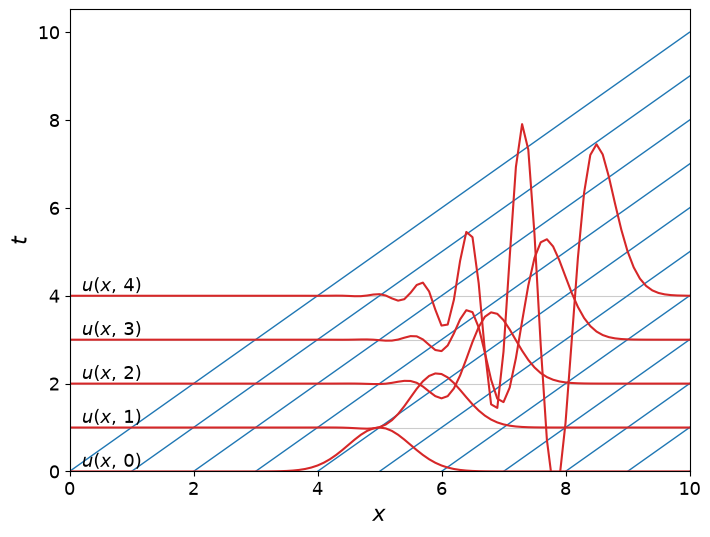

In [6]:
v = 1

## Times I want to see slices at, converted to time-step indices
## (so they stay put when you change delta_t)
t_plot = [0, 1, 2, 3, 4]
n_list = [int(round(t / delta_t)) for t in t_plot]

u_NJ = pde_stepper(u_0,v,delta_t,delta_x,0,0,T_max)
plot_time_slices(u_NJ, delta_x, delta_t, n_list=n_list, v=v)

Not good!  Try playing around with $\Delta t$ and $\Delta x$, and see if you can get things looking a bit more reasonable.  Right now, I'm only plotting 4 time intervals.  What happens if I plot all 10?

# Part 2

So that should have gotten you somewhat closer, but it's very difficult to get the pulse to actually stop at the wall.  To that end, we'll need to imlement **Lax**, a modification to FTCS where we replace the $u_j^n$ with the average of the two spatial points, $\tfrac{1}{2}(u_{j+1}^n + u_{j-1}^2)$

### Write down the above full Lax update, $u_j^{n+1} = \tfrac{1}{2}(u_{j+1}^n + u_{j-1}^n) + \alpha (u_{j+1}^n + u_{j-1}^n)$, as a matrix, then rewrite our above algorithm.  How does this look now?

In [7]:
def lax_step(u_n, v, u_min, u_max, delta_t, delta_x):
    """
    Computes the forward-time, center-space forward update, 
    now with the Lax averaging for the u_j^n, assuming
    Dirichlet boundary conditions.

    Note I'm assuming my boundary conditions are at u[0]
    and u[J], for a vector of size J+1

    Input:
        u_n     -  The vector representing my current spatial slice
        v       -  Velocity
        u_min   -  Left-hand side BC for my spatial interval
        u_max   -  Right-hand side BC for my spatial interval
        delta_t -  Timestep
        delta_x -  spatial difference step

    Output:
        u_np1   -  The array of solutions to my PDE at time n+1
    """

    alpha = v * delta_t / delta_x## YOUR CODE GOES HERE

    ## Note I don't actually need to build this every time!  I could
    ## Just define it once outside of this function which would save time
    M = len(u_n)
    A = np.eye(M) * 0.5 ## YOUR CODE GOES HERE
    j = np.arange(1, M - 1)

    ## Some fancy NumPy index manipulation
    A[j, j - 1] =  ## YOUR CODE GOES HERE
    A[j, j + 1] =  ## YOUR CODE GOES HERE

    ## Then just matrix-vector multiplication
    u_np1 = A@u_n

    return u_np1


SyntaxError: invalid syntax (3902632096.py, line 22)

### Now try running and plotting again (with our initial, crappy timesteps)

In [ ]:
## First draw my initial data, starting at t=0, on a grid
## from x=0 to x=10 with spacing delta_x, with the Gaussian
## centered at x_0=5

delta_t = 0.1
delta_x = 0.1
T_max = 10
X_max = 10

## Number of spatial intervals that fit in [0, X_max] (so J+1 grid points)
J = int(round(X_max / delta_x))

Gaussian_center = 5
Gaussian_sigma = 0.5

u_0 = gaussian_ic(J,0,X_max,x_0=Gaussian_center,sigma=Gaussian_sigma)

## They're almost zero anyway, but I'll enforce the Dirchilet BCs
## just to be safe
u_0[0] = 0
u_0[J] = 0

In [ ]:
v = 1

## Times I want to see slices at, converted to time-step indices
## (so they stay put when you change delta_t)
t_plot = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
n_list = [int(round(t / delta_t)) for t in t_plot]

u_NJ = pde_stepper(u_0,v,delta_t,delta_x,0,0,T_max)
plot_time_slices(u_NJ, delta_x, delta_t, n_list=n_list, v=v)


In [ ]:
import numpy as np
p = np.array([[1, 2],[3,4]])
print(p[1,0])